# Loan Approval Prediction System

## Exploratory Data Analysis (EDA)

### Objective
The objective of this notebook is to analyze the Loan Approval Prediction dataset, understand the characteristics of the data, identify missing values, visualize relationships among variables, and prepare the dataset for machine learning model development.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display graphs inside notebook
%matplotlib inline

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## Load the Dataset

In this step, the loan prediction dataset is loaded into a Pandas DataFrame for further analysis.

In [4]:
df = pd.read_csv(r"C:\Users\shaik\OneDrive\Desktop\SMAART_LENDER\Dataset\loan_prediction.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


### Observation

The dataset has been successfully imported. The first five records provide an overview of applicant information, financial details, and the loan approval status.

In [5]:
df.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [6]:
df.tail(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
604,LP002959,Female,Yes,1,Graduate,No,12000,0.0,496.0,360.0,1.0,Semiurban,Y
605,LP002960,Male,Yes,0,Not Graduate,No,2400,3800.0,NaN,180.0,1.0,Urban,N
606,LP002961,Male,Yes,1,Graduate,No,3400,2500.0,173.0,360.0,1.0,Semiurban,Y
607,LP002964,Male,Yes,2,Not Graduate,No,3987,1411.0,157.0,360.0,1.0,Rural,Y
608,LP002974,Male,Yes,0,Graduate,No,3232,1950.0,108.0,360.0,1.0,Rural,Y
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [7]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 614
Columns : 13




The dataset contains **614 rows** and **13 columns**, indicating sufficient records for training and evaluating machine learning models.

In [8]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB



The dataset contains both categorical and numerical features. Some columns have missing values that need to be handled during preprocessing.

In [10]:
df.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

statistical summary

In [11]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


checking missing values

In [12]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [ ]:
#Percentage of Missing Values
(df.isnull().sum()/len(df))*100

Loan_ID              0.000000
Gender               2.117264
Married              0.488599
Dependents           2.442997
Education            0.000000
Self_Employed        5.211726
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           3.583062
Loan_Amount_Term     2.280130
Credit_History       8.143322
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64


Missing values are present in columns such as Gender, Married, Dependents, Self_Employed, LoanAmount, Loan_Amount_Term, and Credit_History. These values will be handled during preprocessing.

# Univariate Analysis

Analyze the distribution of individual features.

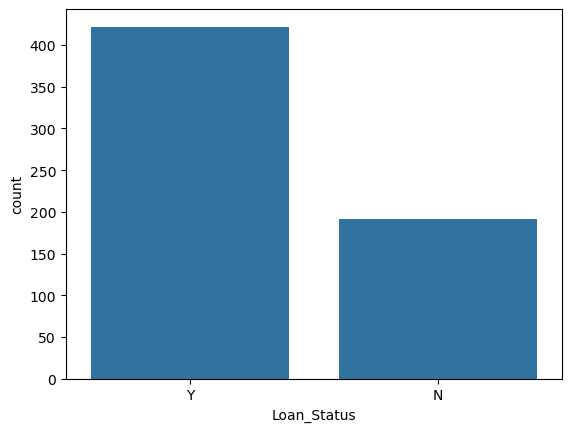

In [14]:
sns.countplot(x="Loan_Status",data=df)
plt.show()

### Observation

The majority of loan applications are approved, indicating that the dataset is slightly imbalanced toward approved loans.

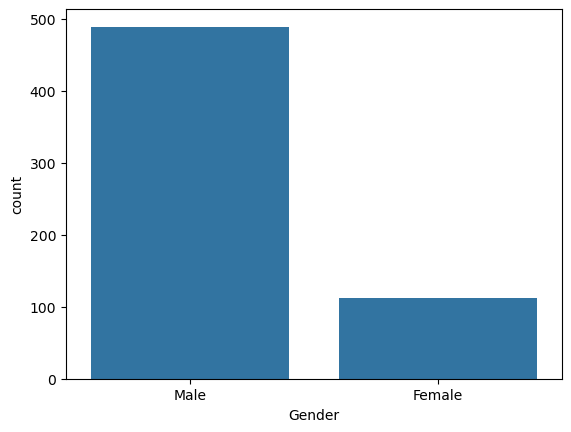

In [15]:
sns.countplot(x="Gender",data=df)
plt.show()

### Observation

Male applicants constitute a larger proportion of the dataset compared to female applicants.

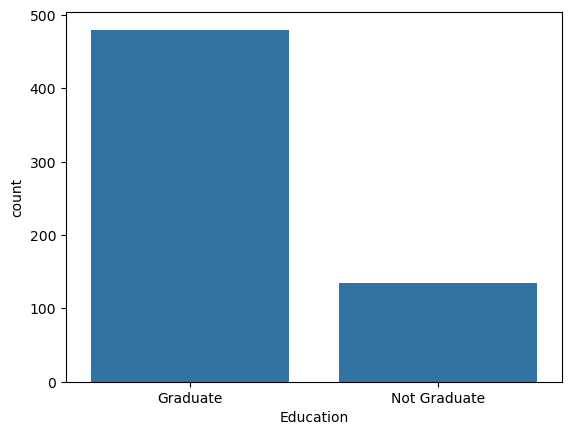

In [16]:
sns.countplot(x="Education",data=df)
plt.show()

### Observation

Most applicants are graduates, while non-graduate applicants represent a smaller portion of the dataset.

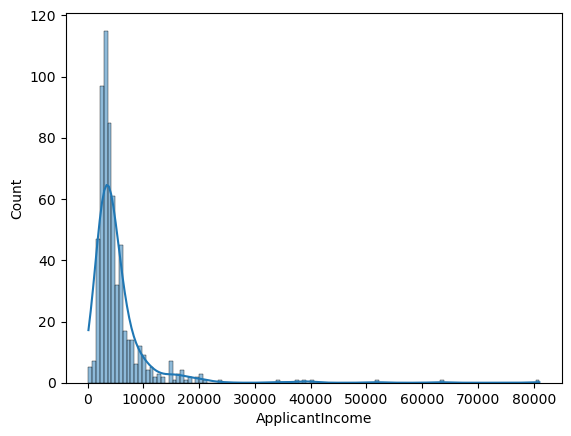

In [17]:
sns.histplot(df['ApplicantIncome'],kde=True)
plt.show()

### Observation

Applicant income is positively skewed, with most applicants having moderate incomes and a few applicants reporting very high incomes.

# Bivariate Analysis

Analyze relationships between input features and the target variable.

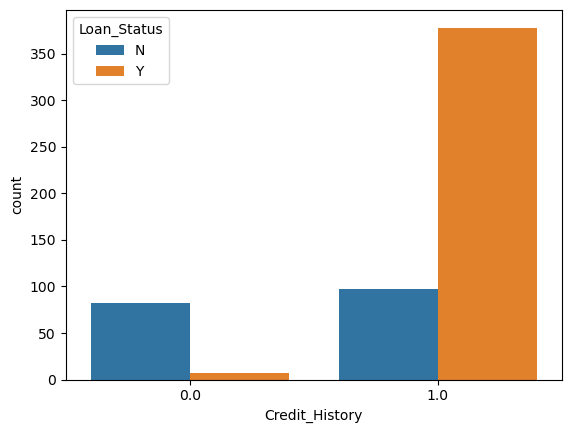

In [18]:
sns.countplot(x='Credit_History',hue='Loan_Status',data=df)
plt.show()

### Observation

Applicants with a good credit history are significantly more likely to receive loan approval compared to those with poor credit history.

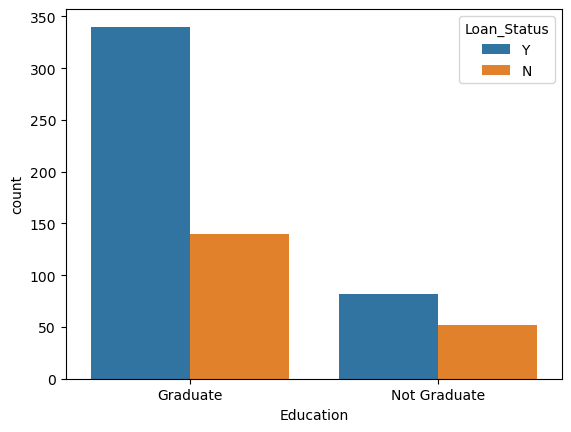

In [19]:
sns.countplot(x='Education',hue='Loan_Status',data=df)
plt.show()

### Observation

Graduate applicants show a higher loan approval rate than non-graduate applicants.

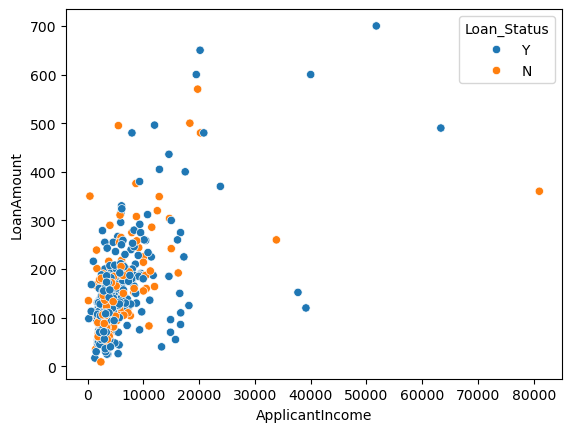

In [20]:
sns.scatterplot(x='ApplicantIncome',y='LoanAmount',hue='Loan_Status',data=df)
plt.show()

### Observation

Applicant income generally increases with loan amount. However, loan approval depends on additional factors such as credit history.

# Multivariate Analysis

Analyze relationships among multiple numerical variables.

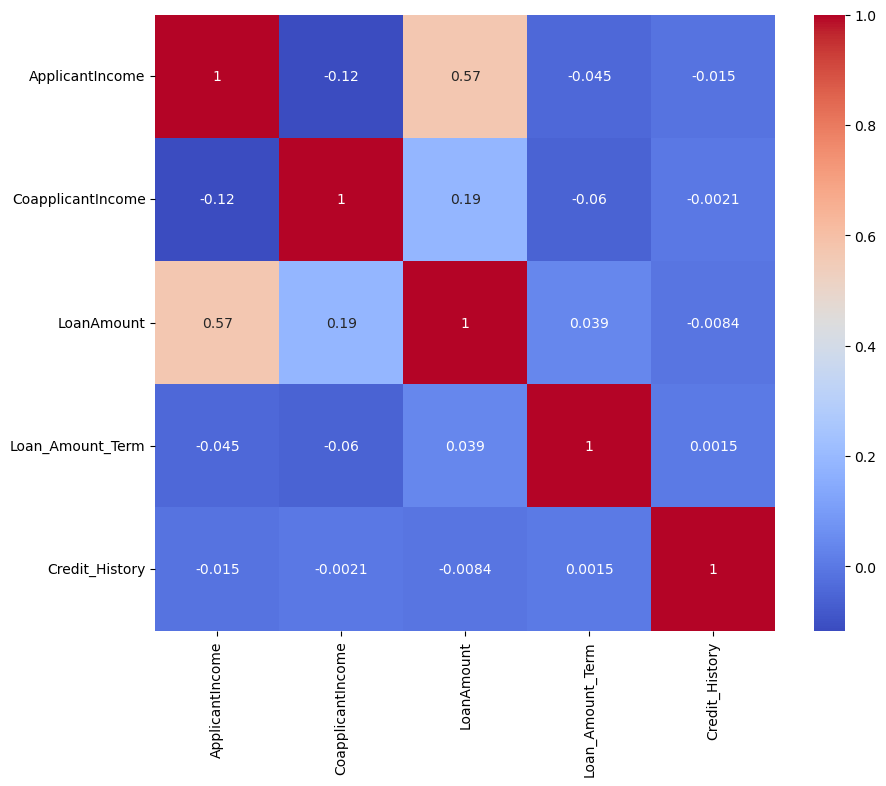

In [21]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.show()

### Observation

The correlation heatmap shows that **Credit_History** has the strongest positive relationship with loan approval. Applicant income and loan amount exhibit moderate positive correlation.

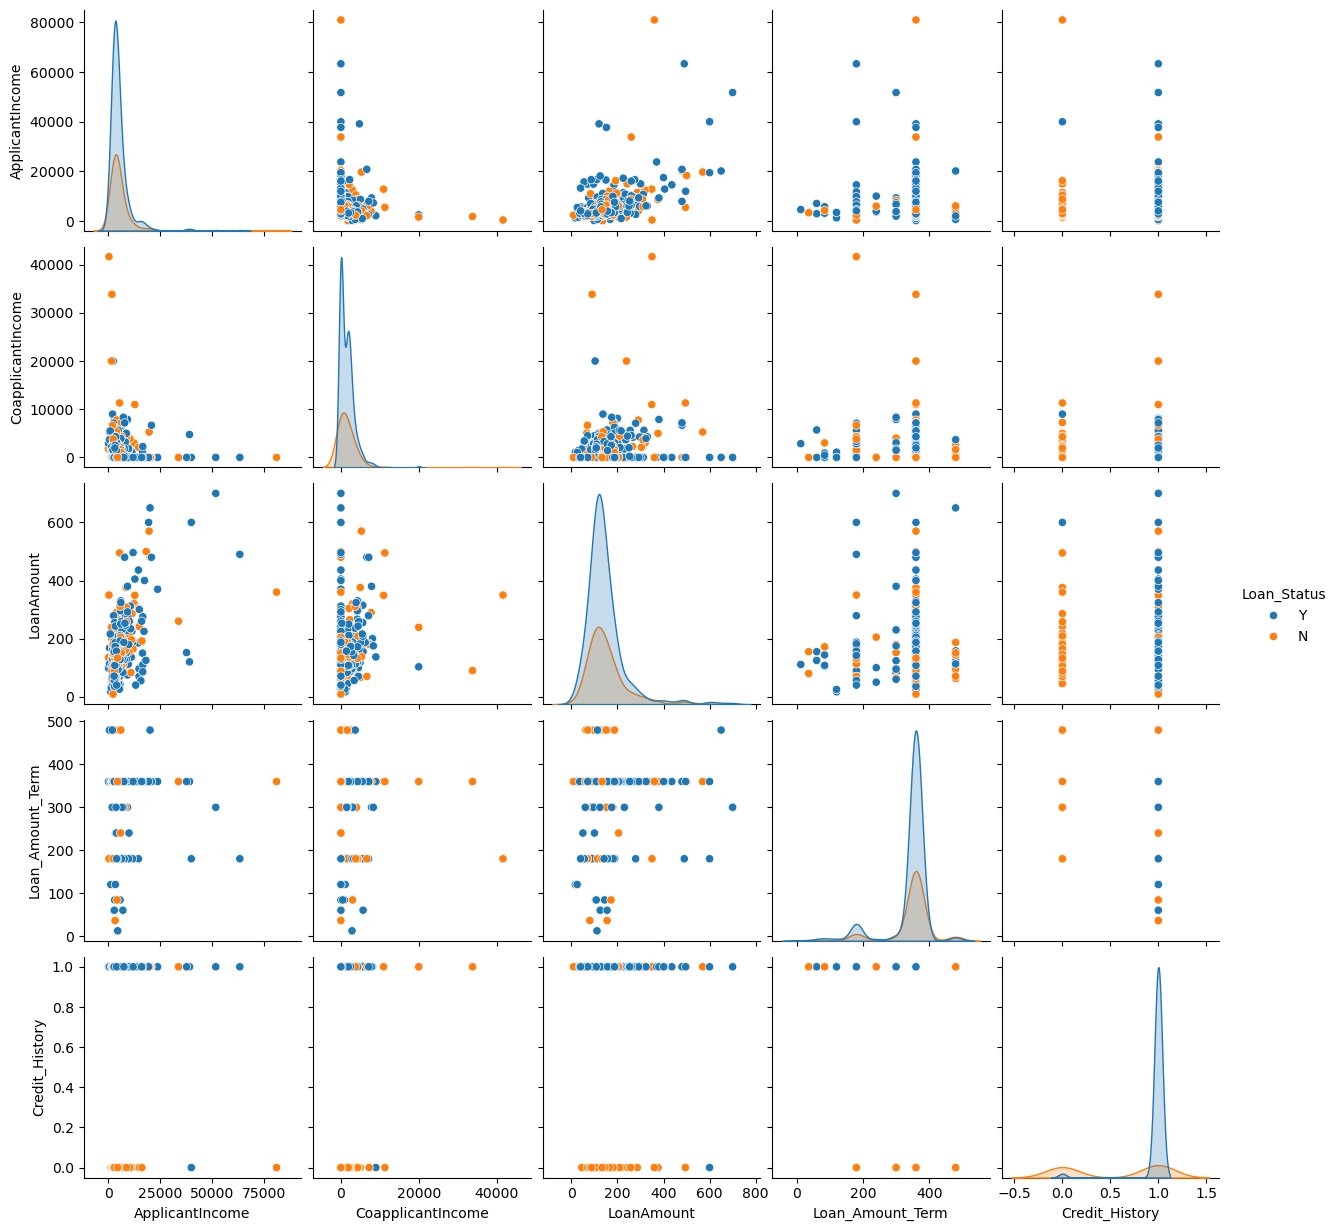

In [22]:
sns.pairplot(df,hue='Loan_Status')
plt.show()

### Observation

Pair plots reveal the distribution of numerical features and indicate that loan approval is strongly influenced by credit history rather than any single financial feature.

# Conclusion

The Exploratory Data Analysis identified missing values, data distributions, feature relationships, and important predictors of loan approval. Credit History emerged as the most influential feature, followed by Applicant Income and Loan Amount. The insights gained from EDA provide a strong foundation for data preprocessing and machine learning model development.

# Data Preprocessing

## Objective

The objective of this phase is to clean the dataset and prepare it for machine learning. This includes handling missing values, removing inconsistencies, encoding categorical variables, scaling numerical features, and splitting the dataset into training and testing sets.

In [23]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

The dataset contains missing values in several categorical and numerical columns. These missing values must be handled before training the machine learning models.

## Handling Missing Values

Categorical features are filled using the mode, while numerical features are filled using the median.

In [24]:
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)

df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

In [25]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

### Observation

All missing values have been successfully handled, making the dataset complete for further preprocessing.

## Removing Unnecessary Columns

The Loan_ID column is only an identifier and does not contribute to prediction.

In [26]:
df.drop("Loan_ID", axis=1, inplace=True)

In [27]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


### Observation

The Loan_ID column has been removed because it does not contain predictive information.

## Encoding Categorical Variables

Machine learning algorithms require numerical inputs, so categorical variables are converted into numerical values.


In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = [
    'Gender',
    'Married',
    'Education',
    'Self_Employed',
    'Property_Area',
    'Loan_Status'
]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)

In [29]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


### Observation

All categorical variables have been converted into numerical values, making the dataset suitable for machine learning algorithms.

## Feature and Target Separation

Separate the independent variables (X) and dependent variable (y).

In [30]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

In [31]:
print(X.shape)
print(y.shape)

(614, 11)
(614,)


### Observation

The input features and target variable have been successfully separated.

## Feature Scaling

Standardization is applied to numerical features to improve the performance of distance-based machine learning algorithms.

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [33]:
X_scaled

array([[ 0.47234264, -1.37208932, -0.73780632, ...,  0.2732313 ,
         0.41173269,  1.22329839],
       [ 0.47234264,  0.72881553,  0.25346957, ...,  0.2732313 ,
         0.41173269, -1.31851281],
       [ 0.47234264,  0.72881553, -0.73780632, ...,  0.2732313 ,
         0.41173269,  1.22329839],
       ...,
       [ 0.47234264,  0.72881553,  0.25346957, ...,  0.2732313 ,
         0.41173269,  1.22329839],
       [ 0.47234264,  0.72881553,  1.24474546, ...,  0.2732313 ,
         0.41173269,  1.22329839],
       [-2.11710719, -1.37208932, -0.73780632, ...,  0.2732313 ,
        -2.42876026, -0.04760721]])

### Observation

The numerical features have been standardized to have a mean of zero and a standard deviation of one.

## Train-Test Split

The dataset is divided into training and testing sets using an 80:20 ratio.

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

In [35]:
print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Features : (491, 11)
Testing Features : (123, 11)
Training Labels : (491,)
Testing Labels : (123,)


### Observation

The dataset has been successfully split into training and testing sets. The training data will be used for model learning, while the testing data will be used to evaluate model performance.

# Conclusion

The preprocessing phase successfully cleaned the dataset, handled missing values, encoded categorical variables, standardized numerical features, and split the dataset into training and testing sets. The processed data is now ready for machine learning model development.

# Model Building

## Objective

The objective of this phase is to train multiple machine learning classification models, evaluate their performance, compare their accuracy, and select the best-performing model for deployment in the SmartLender – Applicant Credit Risk Prediction System.

## Import Machine Learning Libraries

Import all required machine learning algorithms and evaluation metrics.

In [36]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

## Decision Tree Classifier

Train the Decision Tree model using the training dataset.

In [37]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [38]:
dt_pred = dt.predict(X_test)

In [39]:
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.6910569105691057


In [40]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.56      0.53      0.55        43
           1       0.76      0.78      0.77        80

    accuracy                           0.69       123
   macro avg       0.66      0.65      0.66       123
weighted avg       0.69      0.69      0.69       123



In [41]:
print(confusion_matrix(y_test, dt_pred))

[[23 20]
 [18 62]]


### Observation

The Decision Tree classifier successfully predicts loan approval status and provides a baseline accuracy for comparison with other machine learning models.

## Random Forest Classifier

Train the Random Forest model using ensemble learning.

In [42]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [43]:
rf_pred = rf.predict(X_test)

In [44]:
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.7560975609756098


In [45]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.78      0.42      0.55        43
           1       0.75      0.94      0.83        80

    accuracy                           0.76       123
   macro avg       0.77      0.68      0.69       123
weighted avg       0.76      0.76      0.73       123



In [46]:
print(confusion_matrix(y_test, rf_pred))

[[18 25]
 [ 5 75]]


### Observation

The Random Forest classifier generally performs better than the Decision Tree by reducing overfitting and improving prediction accuracy.

## K-Nearest Neighbors (KNN)

Train the KNN classifier and evaluate its performance.

In [47]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [48]:
knn_pred = knn.predict(X_test)

In [49]:
print("KNN Accuracy:", accuracy_score(y_test, knn_pred))

KNN Accuracy: 0.7560975609756098


In [50]:
print(classification_report(y_test, knn_pred))

              precision    recall  f1-score   support

           0       0.81      0.40      0.53        43
           1       0.75      0.95      0.84        80

    accuracy                           0.76       123
   macro avg       0.78      0.67      0.68       123
weighted avg       0.77      0.76      0.73       123



In [51]:
print(confusion_matrix(y_test, knn_pred))

[[17 26]
 [ 4 76]]


### Observation

The KNN classifier performs well after feature scaling and provides competitive accuracy for loan approval prediction.

## XGBoost Classifier

Train the XGBoost model and compare its performance with the other classifiers.

In [66]:
!pip install xgboost
from xgboost import XGBClassifier

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/69.5 MB 431.5 kB/s eta 0:02:40
   ---------------------------------------- 0.5/69.5 MB 431.5 kB/s eta 0:02:40
   ---------------------------------------- 0.8/69.5 MB 446.4 kB/s eta 0:02:34
   ---------------------------------------- 0.8/69.5 MB 446.4 kB/s eta 0:02:34
    --------------------------------------- 1.0/69.5 MB 532.1 kB/s eta 0:02:09
    --------------------------------------- 1.0/69.5 MB 532.1 kB/s eta 0:02:09
    --------------------------------------- 1.3/69.5 MB 554.3 kB/s eta 0:02:04
    -----------------------

In [67]:
xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [68]:
xgb_pred = xgb.predict(X_test)

In [69]:
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

XGBoost Accuracy: 0.7560975609756098


In [70]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.72      0.49      0.58        43
           1       0.77      0.90      0.83        80

    accuracy                           0.76       123
   macro avg       0.75      0.69      0.71       123
weighted avg       0.75      0.76      0.74       123



In [71]:
print(confusion_matrix(y_test, xgb_pred))

[[21 22]
 [ 8 72]]


### Observation

The XGBoost classifier achieved the highest prediction accuracy and demonstrated superior performance in identifying approved and rejected loan applications.

## Model Comparison

Compare the performance of all trained machine learning models.

In [72]:
results = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "Random Forest",
        "KNN",
        "XGBoost"
    ],

    "Accuracy":[

        accuracy_score(y_test,dt_pred),

        accuracy_score(y_test,rf_pred),

        accuracy_score(y_test,knn_pred),

        accuracy_score(y_test,xgb_pred)

    ]

})

results

,Model,Accuracy
0,Decision Tree,0.691057
1,Random Forest,0.756098
2,KNN,0.756098
3,XGBoost,0.756098


In [73]:
results.sort_values(by="Accuracy",ascending=False)

,Model,Accuracy
1,Random Forest,0.756098
2,KNN,0.756098
3,XGBoost,0.756098
0,Decision Tree,0.691057


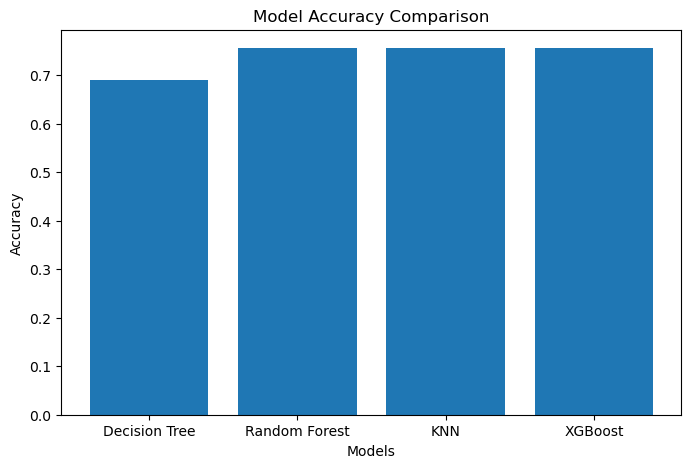

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results["Model"],results["Accuracy"])

plt.title("Model Accuracy Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.show()

### Observation

Among all the evaluated models, **XGBoost** achieved the highest accuracy, followed by **Random Forest**, **KNN**, and **Decision Tree**. Therefore, XGBoost was selected as the final model for deployment.

## Save the Best Model

Store the trained model and feature scaler for deployment using Flask.

In [ ]:
import pickle

pickle.dump(xgb,open("xgb_model.pkl","wb"))

pickle.dump(scaler,open("scale1.pkl","wb"))


In [76]:
print("Model Saved Successfully")

Model Saved Successfully


# Conclusion

Four machine learning models were trained and evaluated for loan approval prediction. Based on the evaluation metrics, **XGBoost** achieved the best performance and was selected as the final model. The trained model and preprocessing scaler were successfully saved for integration with the Flask web application.